## Library 준비

In [1]:
## 데이터 분석 & 시각화 관련 library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Machine Learning Algorithm Library (scikit-learn)
from sklearn.linear_model import LogisticRegression  # two-class classification
from sklearn.svm import SVC, LinearSVC  # SVC: kernel SVM / LinearSVC: linear SVM
from sklearn.ensemble import RandomForestClassifier  # 여러 트리를 모아 예측
from sklearn.neighbors import KNeighborsClassifier  # 가장 가까운 k개의 이웃을 기준으로 분류
from sklearn.naive_bayes import GaussianNB  # 독립 가정 + normal dist 기반 확률 분류
from sklearn.linear_model import Perceptron, SGDClassifier  # 고전적 이진 분류 / 경사하강법 기반 선형분류
from sklearn.tree import DecisionTreeClassifier  # 분기 규칙 기반으로 예측

In [2]:
sns.load_dataset("titanic")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
train_df = pd.read_csv('train_1.csv')
test_df = pd.read_csv('test_1.csv')

In [4]:
train_df  # 891*12

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
test_df  # 418*11

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## 타이타닉데이터 합쳐서 분석하기
- Name이라는 피처가 단순하게 이름일 수 있지만, 결혼유무나 성별을 확인할 수 있는 하나의 피처로도 바라볼 수 있다.
- 이 피처를 통해 우리가 결혼이나 다른 피처를 추가해서 만들 수 있다.

- Name 어떤 식으로 가공할까?
- 문자열, 정규표현식 이용해서 피처를 가공할 수 있다.
- 정규표현식을 이용한 피처 가공 (Name 피처)

- Name 칼럼은 단순한 이름이 아니라
- 사람의 지위, 성별, 결혼 유무 등을 암시하는 정보가 숨어있음
- ex; "Mr.", "Mrs.", "Miss.", "Master.", "Dr.", "Rev.", etc.

In [6]:
## 불필요한 column 삭제(drop)
train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)  # axis=1 : 열 방향
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)

## 전처리를 train_df, test_df 모두에 일괄 적용하기 위해 dataframe을 list로 묶음
## 이후 for 반복문으로 처리 가능
combine = [train_df, test_df]

In [7]:
combine

[     PassengerId  Survived  Pclass  \
 0              1         0       3   
 1              2         1       1   
 2              3         1       3   
 3              4         1       1   
 4              5         0       3   
 ..           ...       ...     ...   
 886          887         0       2   
 887          888         1       1   
 888          889         0       3   
 889          890         1       1   
 890          891         0       3   
 
                                                   Name     Sex   Age  SibSp  \
 0                              Braund, Mr. Owen Harris    male  22.0      1   
 1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
 2                               Heikkinen, Miss. Laina  female  26.0      0   
 3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
 4                             Allen, Mr. William Henry    male  35.0      0   
 ..                                               

## Name 컬럼 전처리
- str 문법
- 문자열 데이터에 대한 전처리 작업 진행시 사용
- 시리즈, 데이터프레임으로 잡고 -> str.원하는문법 (extract, findall, etc.)
- 정규표현식을 사용

- 머신러닝 모델은 문자열을 직접 다루지 못하므로, 필요한 정보를 수치화 or 범주화
- 정규 표현식을 활용하여 Name에서 Title(사회적 지위, 성별, etc.를 유추할 수 있는 호칭)을 추출해 새로운 feature로 저장

In [8]:
## Name에서 Mr., Mrs., Miss. 추출해서 'Name_re'에 저장
for df in combine:
  df['Name_re'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=True)  # 위에 str. 문법

In [9]:
## 실제 성별과 'Name_re'가 만든 feature가 실제로 잘 매핑이 되었는지 간단한 검증
## pd.crosstab()은 엑셀의 피벗 테이블처럼 두 범주형 변수 간의 빈도(횟수) 관계를 보여줌
## 'Mr.'는 모두 'male'이면 신뢰도 높음. 잘 작동한 것

pd.crosstab(train_df['Name_re'], train_df['Sex'])

Sex,female,male
Name_re,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [10]:
pd.crosstab(train_df['Name_re'], train_df['Pclass'])

Pclass,1,2,3
Name_re,,,
Capt,1,0,0
Col,2,0,0
Countess,1,0,0
Don,1,0,0
Dr,5,2,0
Jonkheer,1,0,0
Lady,1,0,0
Major,2,0,0
Master,3,9,28


## Feature Engineering
- 단순히 피처 수를 늘리는 것이 아니라 y값을 잘 구분해줄 수 있는 정보가 있는 피처를 만드는 것이 중요
- 유사한 것들끼리 묶어서 범주화:

- 그냥 그대로 다 가지고 간다. 나눈 것들을 그대로 옆에 컬럼을 붙이는 경우
- 피처의 값들의 범위가 너무 넓어지고 y값에 따른 구분할 수 있는 피처를 만드는 게 아니라 의미 없이 피처를 하나더 만드는 것은 -> 차원이 하나 더 추가 되는 것
- 차원이 하나 더 추가되면 데이터 상에서 멀어지고 복잡해진다.
- 성별과 생존의 유무가 확실히 보였다.
- 이 부분을 응용해서 진행
- 전체 다 사용하는 게 아니라, 구간화해서 묶어주는 작업 그룹화 작업의 개념, bining 그룹핑으로 데이터를 묶는다.
- 유사한 것들끼리, 이 기준은 우리는 Y값과 기존에 탐색했던 성별 컬럼을 보고 의사결정 진행

In [11]:
## replace 파이썬 기초 문법
for df in combine:
  # 드문 성들은 'Rare'로
  df['Name_re'] = df['Name_re'].replace(['Lady', 'Countess', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Doha'], 'Rare')
  # 'Mlle' -> 'Miss'
  df['Name_re'] = df['Name_re'].replace('Mlle', 'Miss')
  # 'Ms' -> 'Miss'
  df['Name_re'] = df['Name_re'].replace('Ms', 'Miss')
  # 'Mme' -> 'Miss'
  df['Name_re'] = df['Name_re'].replace('Mme', 'Miss')

In [12]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,Mr


In [13]:
## 간단하게 groupby로 살펴보자
## 'Name_re'에 따른 'Survived'의 평균 계산. 즉, 'Name_re'에 따른 생존률 파악
train_df[['Name_re', 'Survived']].groupby(['Name_re'], as_index=False).mean()

,Name_re,Survived
0,Capt,0.000000
1,Master,0.575000
2,Miss,0.704301
3,Mr,0.156673
4,Mrs,0.792000
5,Rare,0.363636


In [14]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,Mr


## Encoding
- 범주형 변수를 수치형 변수로 변환
- Name_re 에서 나온 값들을 -> 수치로 변경하는 것
- 레이블인코딩, 원핫인코딩. 그외에 인코딩도 많지만 대표적으로 이 두 가지

- 레이블인코딩 : 1,2,3,4,5,6 해당 값에 순서를 매칭해서 변경해 준다.
  - Mr 1 Mrs 2, Rare 3, Miss 4 등등
- 원핫인코딩 : 0,1로만 피처를 만들어 준다.
  - Mr, Mrs, Rare, Miss 컬럼으로 만들어 준다.
  - 이 컬럼에 대응하는 값이 0,1 인지를 인덱스기준으로 매핑한다.

## Name_re 컬럼 전처리
- 레이블 인코딩으로

In [15]:
## 레이블 인코딩
name_re = {'Mr':1, 'Miss':2, 'Mrs':3, 'Master':4, 'Rare':5}

for df in combine:
  df['Name_re'] = df['Name_re'].map(name_re)  # map함수를 통해 해당 값으로 변환
  df['Name_re'] = df['Name_re'].fillna(0)  # 결측치는 0으로 대체

In [16]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,3.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,3.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,5.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,2.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S,2.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,1.0


In [17]:
train_df[['Sex', 'Survived']].groupby(['Sex'], as_index=False).mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [18]:
## 전처리 진행 후 사용한 컬럼은 제거
train_df = train_df.drop(['Name', 'PassengerId'], axis=1)
test_df = test_df.drop(['Name'], axis=1)

In [19]:
combine = [train_df, test_df]

In [20]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,0,3,male,22.0,1,0,7.2500,S,1.0
1,1,1,female,38.0,1,0,71.2833,C,3.0
2,1,3,female,26.0,0,0,7.9250,S,2.0
3,1,1,female,35.0,1,0,53.1000,S,3.0
4,0,3,male,35.0,0,0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,5.0
887,1,1,female,19.0,0,0,30.0000,S,2.0
888,0,3,female,NaN,1,2,23.4500,S,2.0
889,1,1,male,26.0,0,0,30.0000,C,1.0


## Sex 컬럼 전처리
- 원핫 인코딩의 개념으로
- Sex 를 전처리하기 딱 좋은 Male, Female -> 0,1
- 생존확률이 높은 사람은 여성이었고, 여성을 1, 남성을 0

In [21]:
## 남성과 여성도 원핫 인코딩의 개념으로 인코딩 진행

for df in combine:
  df['Sex'] = df['Sex'].map({'female':1, 'male':0}).astype(int)

In [22]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,0,3,0,22.0,1,0,7.2500,S,1.0
1,1,1,1,38.0,1,0,71.2833,C,3.0
2,1,3,1,26.0,0,0,7.9250,S,2.0
3,1,1,1,35.0,1,0,53.1000,S,3.0
4,0,3,0,35.0,0,0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,S,5.0
887,1,1,1,19.0,0,0,30.0000,S,2.0
888,0,3,1,NaN,1,2,23.4500,S,2.0
889,1,1,0,26.0,0,0,30.0000,C,1.0


In [23]:
test_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,892,3,0,34.5,0,0,7.8292,Q,1.0
1,893,3,1,47.0,1,0,7.0000,S,3.0
2,894,2,0,62.0,0,0,9.6875,Q,1.0
3,895,3,0,27.0,0,0,8.6625,S,1.0
4,896,3,1,22.0,1,1,12.2875,S,3.0
...,...,...,...,...,...,...,...,...,...
413,1305,3,0,NaN,0,0,8.0500,S,1.0
414,1306,1,1,39.0,0,0,108.9000,C,0.0
415,1307,3,0,38.5,0,0,7.2500,S,1.0
416,1308,3,0,NaN,0,0,8.0500,S,1.0


In [24]:
## 결측값 확인 -> 결측값이면 True, 아니면 False
train_df.isna()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False


In [25]:
## 결측값의 개수 확인 -> True:1, False:0으로 간주돼서 열별로 sum
train_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
Name_re,0


In [26]:
## -> age 컬럼에 결측치가 많은 것을 확인할 수 있음

## age 컬럼 전처리
- Missing Value 대체하는 방법
- MICE
- 보간법
- 단순한 기초통계치로 대체하는 법
- KNN, ML 기법을 통해서 대체하는 법

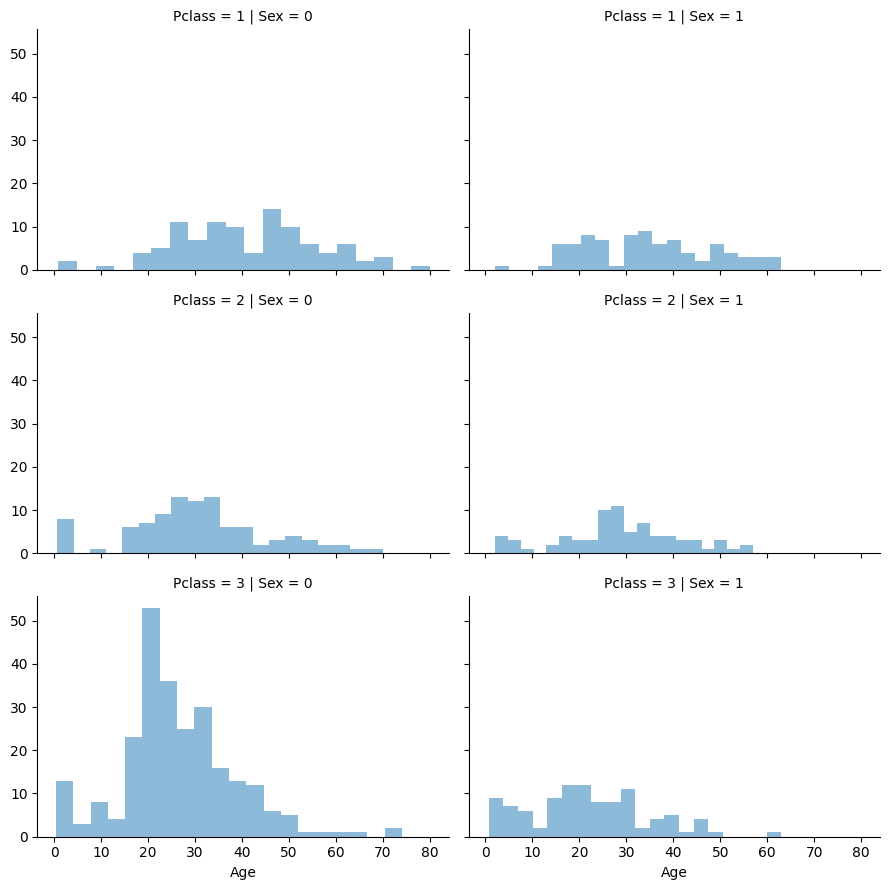

In [27]:
## Pclass, Sex 두 개의 범주형 변수에 따른 Age 분포
grid = sns.FacetGrid(train_df, row='Pclass', col='Sex', aspect=1.5)  # 3*2 = 6개의 서브플롯 생성
grid.map(plt.hist, 'Age', alpha=.5, bins=20)

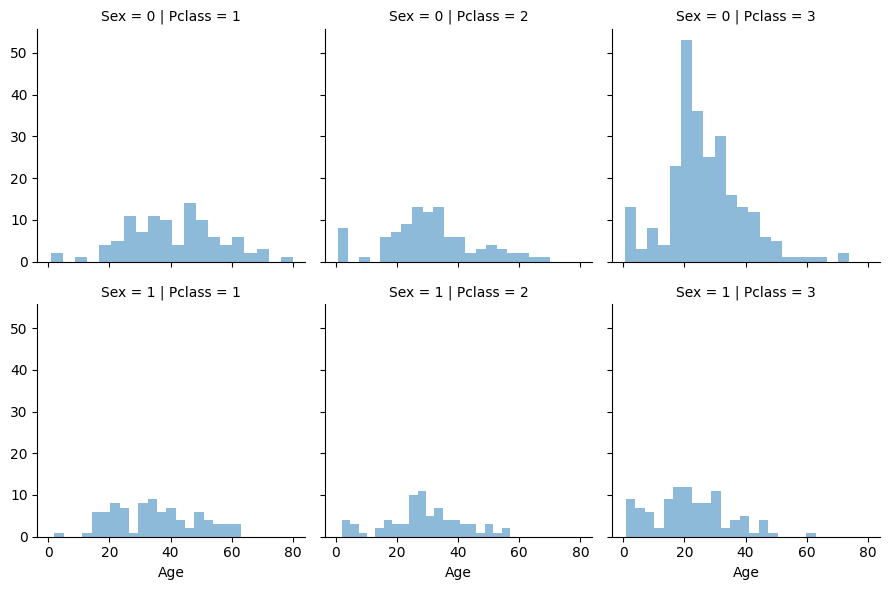

In [28]:
grid = sns.FacetGrid(train_df, row='Sex', col='Pclass', aspect=1)  # 2*3
grid.map(plt.hist, 'Age', alpha=.5, bins=20)

- 결측치를 단순하게 Age 평균으로 대체하면 -> Median
- Sex, Pclass 따라서 2차원으로 나눈 후 -> 그 값들의 Median, Mean 대체를 한다.

In [29]:
## np.zeros : 0값 넣음. 즉, 일단 na값을 채워 넣을 주머니 생성
## 2*3 = 6개 그룹에 대해 평균 나이를 저장할 빈 배열 생성
guess_ages = np.zeros((2, 3))

In [30]:
guess_ages

array([[0., 0., 0.],
       [0., 0., 0.]])

In [31]:
combine

[     Survived  Pclass  Sex   Age  SibSp  Parch     Fare Embarked  Name_re
 0           0       3    0  22.0      1      0   7.2500        S      1.0
 1           1       1    1  38.0      1      0  71.2833        C      3.0
 2           1       3    1  26.0      0      0   7.9250        S      2.0
 3           1       1    1  35.0      1      0  53.1000        S      3.0
 4           0       3    0  35.0      0      0   8.0500        S      1.0
 ..        ...     ...  ...   ...    ...    ...      ...      ...      ...
 886         0       2    0  27.0      0      0  13.0000        S      5.0
 887         1       1    1  19.0      0      0  30.0000        S      2.0
 888         0       3    1   NaN      1      2  23.4500        S      2.0
 889         1       1    0  26.0      0      0  30.0000        C      1.0
 890         0       3    0  32.0      0      0   7.7500        Q      1.0
 
 [891 rows x 9 columns],
      PassengerId  Pclass  Sex   Age  SibSp  Parch      Fare Embarked  Na

In [32]:
## 결측치를 채울 코드는?
## Sex, Pclass 두 가지의 차원으로 결측치를 바라볼 것
## 두 가지의 feature로 값을 추출하면서, 이 값의 median 값을 'guess_ages'에 넣어서 대체
## age는 22.1살, 22.7살은 존재X -> 반올림을 하는 작업도 진행해야됨

for df in combine:
  # Sex, Pclass에 따른 Age 그룹 중앙값 구하는 코드
  for i in range(0, 2):    # i = 0 (male), 1 (female)
    for j in range(0, 3):  # j = 0,1,2 -> Pclass = j+1 = 1,2,3
      # 결측치가 아닌 값만 추출해서 guess_df에 저장
      guess_df = df[(df['Sex'] == i) & (df['Pclass'] == j+1)]['Age'].dropna()

      # 결측치 아닌 값들로 평균을 내서 age_guess에 저장
      age_guess = guess_df.median()

      # 0.5 단위로 반올림하는 테크닉
      guess_ages[i, j] = (age_guess/0.5 + 0.5) * 0.5


  # 결측치 채우기
  for i in range(0, 2):
    for j in range(0, 3):
      # 조건: Age가 결측치이고, Sex=i,Pclass=j+1인 행만 골라서 -> 그 그룹의 중앙값 guess_ages[i,j]로 Age 채우기
      df.loc[(df.Age.isnull()) & (df.Sex == i) & (df.Pclass == j+1), 'Age'] = guess_ages[i, j]

  df['Age'] = df['Age'].astype(int)

In [33]:
## 결측치 모두 채워졌는지 확인
train_df.Age.isna().sum()

np.int64(0)

In [34]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,0,3,0,22,1,0,7.2500,S,1.0
1,1,1,1,38,1,0,71.2833,C,3.0
2,1,3,1,26,0,0,7.9250,S,2.0
3,1,1,1,35,1,0,53.1000,S,3.0
4,0,3,0,35,0,0,8.0500,S,1.0


## Q. 왜 우리가 구간을 나누고 계속해서 전처리를 하는가?
- age 데이터 범위가 넓다.
- 판다스 문법을 통해 쉽게 구간을 나눌 수 있다.
- cut, qcut (나누는 개념)

In [35]:
## 각각의 나이 값이 몇 번 나타났는지
train_df.Age.value_counts()

,count
Age,
25,117
21,66
30,36
40,36
24,31
...,...
66,1
12,1
53,1


In [36]:
max(train_df['Age'])

80

In [37]:
min(train_df['Age'])

0

In [38]:
## Age 변수를 5개의 구간(bins)으로 범주형 데이터로 변환
train_df['Agerange'] = pd.cut(train_df['Age'], 5)

In [39]:
## 단순하게 그냥 구간을 나누고 마음대로 할 수 있는 게 아니라 위와 동일하게 y값의 관계를 살펴보자!
## 나이 구간(Agerange)에 따른 생존률의 평균 계산, 나이 구간별로 내림차순 정렬

train_df[['Agerange', 'Survived']].groupby(['Agerange'], as_index=False).mean().sort_values(by='Agerange', ascending=False)

<ipython-input-39-2873638634>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df[['Agerange', 'Survived']].groupby(['Agerange'], as_index=False).mean().sort_values(by='Agerange', ascending=False)


,Agerange,Survived
4,"(64.0, 80.0]",0.090909
3,"(48.0, 64.0]",0.434783
2,"(32.0, 48.0]",0.412037
1,"(16.0, 32.0]",0.337374
0,"(-0.08, 16.0]",0.550000


## 인코딩하는 작업으로 'Age' 데이터 전처리

In [40]:
## 구간을 나누고 각 구간을 0,1,2,3,4 값으로 인코딩
for df in combine:
  df.loc[df['Age'] <= 16, 'Age'] = 0
  df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
  df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
  df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
  df.loc[(df['Age'] > 64), 'Age'] = 4

In [41]:
train_df.Age.value_counts()

,count
Age,
1,495
2,216
0,100
3,69
4,11


In [42]:
## 전처리 후 불필요한 컬럼 삭제
train_df = train_df.drop(['Agerange'], axis=1)

In [43]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,0,3,0,1,1,0,7.2500,S,1.0
1,1,1,1,2,1,0,71.2833,C,3.0
2,1,3,1,1,0,0,7.9250,S,2.0
3,1,1,1,2,1,0,53.1000,S,3.0
4,0,3,0,2,0,0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
886,0,2,0,1,0,0,13.0000,S,5.0
887,1,1,1,1,0,0,30.0000,S,2.0
888,0,3,1,1,1,2,23.4500,S,2.0
889,1,1,0,1,0,0,30.0000,C,1.0


## SibSp, Parch
- 두 개 컬럼이 가족과 관련한 동승자와 관려한 컬럼
  - SibSp: 형제/자매, 배우자의 수
  - Parch: 부모, 자녀의 수

- 이 두 가지를 합쳐서 새로운 컬럼을 만들고 그 컬럼을 통해서 feature 가공

- 이 두 가지를 합쳐서 -> 새로운 하나의 파생변수 FamilySize 생성

In [44]:
combine

[     Survived  Pclass  Sex  Age  SibSp  Parch     Fare Embarked  Name_re  \
 0           0       3    0    1      1      0   7.2500        S      1.0   
 1           1       1    1    2      1      0  71.2833        C      3.0   
 2           1       3    1    1      0      0   7.9250        S      2.0   
 3           1       1    1    2      1      0  53.1000        S      3.0   
 4           0       3    0    2      0      0   8.0500        S      1.0   
 ..        ...     ...  ...  ...    ...    ...      ...      ...      ...   
 886         0       2    0    1      0      0  13.0000        S      5.0   
 887         1       1    1    1      0      0  30.0000        S      2.0   
 888         0       3    1    1      1      2  23.4500        S      2.0   
 889         1       1    0    1      0      0  30.0000        C      1.0   
 890         0       3    0    1      0      0   7.7500        Q      1.0   
 
          Agerange  
 0    (16.0, 32.0]  
 1    (32.0, 48.0]  
 2    (16.0

In [45]:
## 본인을 포함한 함께 탑승한 승객 수
for dataset in combine:
  dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1  # 가족과 관련된 컬럼 -> 패밀리 수치로 바꿈

In [46]:
combine

[     Survived  Pclass  Sex  Age  SibSp  Parch     Fare Embarked  Name_re  \
 0           0       3    0    1      1      0   7.2500        S      1.0   
 1           1       1    1    2      1      0  71.2833        C      3.0   
 2           1       3    1    1      0      0   7.9250        S      2.0   
 3           1       1    1    2      1      0  53.1000        S      3.0   
 4           0       3    0    2      0      0   8.0500        S      1.0   
 ..        ...     ...  ...  ...    ...    ...      ...      ...      ...   
 886         0       2    0    1      0      0  13.0000        S      5.0   
 887         1       1    1    1      0      0  30.0000        S      2.0   
 888         0       3    1    1      1      2  23.4500        S      2.0   
 889         1       1    0    1      0      0  30.0000        C      1.0   
 890         0       3    0    1      0      0   7.7500        Q      1.0   
 
          Agerange  FamilySize  
 0    (16.0, 32.0]           2  
 1    (3

In [47]:
combine[0]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re,Agerange,FamilySize
0,0,3,0,1,1,0,7.2500,S,1.0,"(16.0, 32.0]",2
1,1,1,1,2,1,0,71.2833,C,3.0,"(32.0, 48.0]",2
2,1,3,1,1,0,0,7.9250,S,2.0,"(16.0, 32.0]",1
3,1,1,1,2,1,0,53.1000,S,3.0,"(32.0, 48.0]",2
4,0,3,0,2,0,0,8.0500,S,1.0,"(32.0, 48.0]",1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,1,0,0,13.0000,S,5.0,"(16.0, 32.0]",1
887,1,1,1,1,0,0,30.0000,S,2.0,"(16.0, 32.0]",1
888,0,3,1,1,1,2,23.4500,S,2.0,"(16.0, 32.0]",4
889,1,1,0,1,0,0,30.0000,C,1.0,"(16.0, 32.0]",1


In [48]:
train_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,0,3,0,1,1,0,7.2500,S,1.0
1,1,1,1,2,1,0,71.2833,C,3.0
2,1,3,1,1,0,0,7.9250,S,2.0
3,1,1,1,2,1,0,53.1000,S,3.0
4,0,3,0,2,0,0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
886,0,2,0,1,0,0,13.0000,S,5.0
887,1,1,1,1,0,0,30.0000,S,2.0
888,0,3,1,1,1,2,23.4500,S,2.0
889,1,1,0,1,0,0,30.0000,C,1.0


In [49]:
## 'FamilySize'에 따른 생존률 파악, 생존률 값을 기준으로 내림차순 정렬
combine[0][['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


- 가족들과 함께 탑승, 혼자 탑승 이 두 가지의 경우로 나눠서 컬럼을 추가할 수 있다.

In [50]:
for dataset in combine:
  dataset['IsAlone'] = 0  # 'IsAlon' 컬럼 초기값을 0으로 설정
  dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1  # 만약 'FamilySize'가 1이면 이라는 조건 추가

In [51]:
## 'IsAlone'에 따른 생존률 파악
combine[0][['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


- 두 가지 컬럼을 IsAlone 만들어서 전처리 작업 완료

In [52]:
combine[1]

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re,FamilySize,IsAlone
0,892,3,0,2,0,0,7.8292,Q,1.0,1,1
1,893,3,1,2,1,0,7.0000,S,3.0,2,0
2,894,2,0,3,0,0,9.6875,Q,1.0,1,1
3,895,3,0,1,0,0,8.6625,S,1.0,1,1
4,896,3,1,1,1,1,12.2875,S,3.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,1,0,0,8.0500,S,1.0,1,1
414,1306,1,1,2,0,0,108.9000,C,0.0,1,1
415,1307,3,0,2,0,0,7.2500,S,1.0,1,1
416,1308,3,0,1,0,0,8.0500,S,1.0,1,1


In [53]:
train_df
## 중간에 'train_df = train_df.drop(['Agerange'], axis=1)' 작업으로
## combine 리스트와 포인터 연결이 끊겼음

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re
0,0,3,0,1,1,0,7.2500,S,1.0
1,1,1,1,2,1,0,71.2833,C,3.0
2,1,3,1,1,0,0,7.9250,S,2.0
3,1,1,1,2,1,0,53.1000,S,3.0
4,0,3,0,2,0,0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
886,0,2,0,1,0,0,13.0000,S,5.0
887,1,1,1,1,0,0,30.0000,S,2.0
888,0,3,1,1,1,2,23.4500,S,2.0
889,1,1,0,1,0,0,30.0000,C,1.0


In [54]:
test_df
## 중간에 연결이 끊긴 적 없음
## 따라서 combine 작업이 test_df에도 함께 적용됨

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re,FamilySize,IsAlone
0,892,3,0,2,0,0,7.8292,Q,1.0,1,1
1,893,3,1,2,1,0,7.0000,S,3.0,2,0
2,894,2,0,3,0,0,9.6875,Q,1.0,1,1
3,895,3,0,1,0,0,8.6625,S,1.0,1,1
4,896,3,1,1,1,1,12.2875,S,3.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,1,0,0,8.0500,S,1.0,1,1
414,1306,1,1,2,0,0,108.9000,C,0.0,1,1
415,1307,3,0,2,0,0,7.2500,S,1.0,1,1
416,1308,3,0,1,0,0,8.0500,S,1.0,1,1


In [55]:
## train_df에 새로 만든 파생변수 적용 및 더 이상 필요하지 않은 컬럼 삭제
train_df = combine[0].drop(['Agerange', 'SibSp', 'Parch'], axis=1)
test_df = combine[1].drop(['SibSp', 'Parch'], axis=1)

In [56]:
combine[1]
## combine[1]은 상태 유지됨

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name_re,FamilySize,IsAlone
0,892,3,0,2,0,0,7.8292,Q,1.0,1,1
1,893,3,1,2,1,0,7.0000,S,3.0,2,0
2,894,2,0,3,0,0,9.6875,Q,1.0,1,1
3,895,3,0,1,0,0,8.6625,S,1.0,1,1
4,896,3,1,1,1,1,12.2875,S,3.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,1,0,0,8.0500,S,1.0,1,1
414,1306,1,1,2,0,0,108.9000,C,0.0,1,1
415,1307,3,0,2,0,0,7.2500,S,1.0,1,1
416,1308,3,0,1,0,0,8.0500,S,1.0,1,1


In [57]:
## 학습할 데이터 셋으로 다시 셋팅
combine = [train_df, test_df]

In [58]:
combine

[     Survived  Pclass  Sex  Age     Fare Embarked  Name_re  FamilySize  \
 0           0       3    0    1   7.2500        S      1.0           2   
 1           1       1    1    2  71.2833        C      3.0           2   
 2           1       3    1    1   7.9250        S      2.0           1   
 3           1       1    1    2  53.1000        S      3.0           2   
 4           0       3    0    2   8.0500        S      1.0           1   
 ..        ...     ...  ...  ...      ...      ...      ...         ...   
 886         0       2    0    1  13.0000        S      5.0           1   
 887         1       1    1    1  30.0000        S      2.0           1   
 888         0       3    1    1  23.4500        S      2.0           4   
 889         1       1    0    1  30.0000        C      1.0           1   
 890         0       3    0    1   7.7500        Q      1.0           1   
 
      IsAlone  
 0          0  
 1          0  
 2          1  
 3          0  
 4          1  
 .

## Age 컬럼이랑 Pclass 가지고 새로운 변수로 만들기
- 나이와 타이타닉의 선박의 등급이랑 두 개의 갑을 곱해서 하나의 파생변수 만들었다.

In [59]:
for dataset in combine:
  dataset['Age*Pclass'] = dataset['Age']*dataset['Pclass']

In [60]:
for df in combine:
  print(df['Age*Pclass'])

0      3
1      2
2      3
3      2
4      6
      ..
886    2
887    1
888    3
889    1
890    3
Name: Age*Pclass, Length: 891, dtype: int64
0      6
1      6
2      6
3      3
4      3
      ..
413    3
414    2
415    6
416    3
417    3
Name: Age*Pclass, Length: 418, dtype: int64


In [61]:
## 모든 행에서(':') 'Age*Pclass', 'Age','Pclass' 컬럼 출력
train_df.loc[:, ['Age*Pclass', 'Age', 'Pclass']]

,Age*Pclass,Age,Pclass
0,3,1,3
1,2,2,1
2,3,1,3
3,2,2,1
4,6,2,3
...,...,...,...
886,2,1,2
887,1,1,1
888,3,1,3
889,1,1,1


In [62]:
## 결측치 확인
train_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Embarked,2
Name_re,0
FamilySize,0
IsAlone,0
Age*Pclass,0


In [63]:
train_df['Embarked']

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [64]:
train_df['Embarked'].isna().sum()

np.int64(2)

In [65]:
## 'Embarked'컬럼 결측치를 최빈값으로 대체
## 'Embarked'컬럼에서 결측치 제거 후 최빈값 반환
freq_value = train_df['Embarked'].dropna().mode()[0]
freq_value

'S'

In [66]:
## 'Embarked' 데이터 전처리
## 2개의 NA값이 'S'로 대체
for dataset in combine:
  dataset['Embarked'] = dataset['Embarked'].fillna(freq_value)

## 'Embarked'에 따른 생존률 파악, 생존률 기준 내림차순 정렬
train_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [67]:
train_df.isna().sum()  # 결측값이 모두 다 처리가 되었다.

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Embarked,0
Name_re,0
FamilySize,0
IsAlone,0
Age*Pclass,0


In [68]:
## 'Embarked'컬럼 인코딩 진행
for dataset in combine:
  dataset['Embarked'] = dataset['Embarked'].map({'S':0, 'C':1, 'Q':2}).astype(int)  # 문자열 -> 수치

In [69]:
train_df

,Survived,Pclass,Sex,Age,Fare,Embarked,Name_re,FamilySize,IsAlone,Age*Pclass
0,0,3,0,1,7.2500,0,1.0,2,0,3
1,1,1,1,2,71.2833,1,3.0,2,0,2
2,1,3,1,1,7.9250,0,2.0,1,1,3
3,1,1,1,2,53.1000,0,3.0,2,0,2
4,0,3,0,2,8.0500,0,1.0,1,1,6
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,1,13.0000,0,5.0,1,1,2
887,1,1,1,1,30.0000,0,2.0,1,1,1
888,0,3,1,1,23.4500,0,2.0,4,0,3
889,1,1,0,1,30.0000,1,1.0,1,1,1


In [70]:
test_df.isna().sum()  # test_df['Fare']에 NA값 존재

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
Fare,1
Embarked,0
Name_re,0
FamilySize,0
IsAlone,0
Age*Pclass,0


In [71]:
## test_df['Fare'] 결측값을 median으로 대체
test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)

<ipython-input-71-1083238429>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)


## Fare 요금도 동일하게 qcut, cut이용해서 전처리 작업하자
- qcut: 데이터 개수가 동일하게 구간을 나눔
  - 데이터를 균등하게 나누고 싶을 때
  - ex: 소득 상위 25%, 하위 25%, etc.
- cut: 너비가 동일하게 구간을 나눔
  - 나이, 점수처럼 절대적 기준 구간이 의미가 있을 때

In [72]:
train_df['Fare'].max()

512.3292

In [73]:
train_df['Fare'].min()

0.0

In [74]:
## 'Fare'컬럼을 범주형 구간으로 4구간 나누기
train_df['FareBand'] = pd.qcut(train_df['Fare'], 4)

## 'FareBand'에 따른 생존률 파악, 생존률 기준 내림차순 정렬
train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='Survived', ascending=False)

<ipython-input-74-2614184594>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,FareBand,Survived
3,"(31.0, 512.329]",0.581081
2,"(14.454, 31.0]",0.454955
1,"(7.91, 14.454]",0.303571
0,"(-0.001, 7.91]",0.197309


In [75]:
## 각 구간의 데이터 수
train_df.FareBand.value_counts()

,count
FareBand,
"(7.91, 14.454]",224
"(-0.001, 7.91]",223
"(14.454, 31.0]",222
"(31.0, 512.329]",222


In [76]:
## 'Fare'컬럼을 범주형 변수로 수치 인코딩
for dataset in combine:
  dataset.loc[dataset['Fare'] <= 7.91, 'Fare'] = 0
  dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
  dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare'] = 2
  dataset.loc[dataset['Fare'] > 31, 'Fare'] = 3
  dataset['Fare'] = dataset['Fare'].astype(int)

## 불필요한 파생컬럼 'FareBand' 삭제
train_df = train_df.drop(['FareBand'], axis=1)

## combine 업데이트
combine = [train_df, test_df]

In [77]:
train_df

,Survived,Pclass,Sex,Age,Fare,Embarked,Name_re,FamilySize,IsAlone,Age*Pclass
0,0,3,0,1,0,0,1.0,2,0,3
1,1,1,1,2,3,1,3.0,2,0,2
2,1,3,1,1,1,0,2.0,1,1,3
3,1,1,1,2,3,0,3.0,2,0,2
4,0,3,0,2,1,0,1.0,1,1,6
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,1,1,0,5.0,1,1,2
887,1,1,1,1,2,0,2.0,1,1,1
888,0,3,1,1,2,0,2.0,4,0,3
889,1,1,0,1,2,1,1.0,1,1,1


In [78]:
test_df

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Name_re,FamilySize,IsAlone,Age*Pclass
0,892,3,0,2,0,2,1.0,1,1,6
1,893,3,1,2,0,0,3.0,2,0,6
2,894,2,0,3,1,2,1.0,1,1,6
3,895,3,0,1,1,0,1.0,1,1,3
4,896,3,1,1,1,0,3.0,3,0,3
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,1,1,0,1.0,1,1,3
414,1306,1,1,2,3,1,0.0,1,1,2
415,1307,3,0,2,0,0,1.0,1,1,6
416,1308,3,0,1,1,0,1.0,1,1,3


## 모델링을 통해 성능을 비교해 보자!
- 성능의 비교는 **전처리를 하기 전과 후로 비교**하여 성능의 변화 값 확인!
  - 둘 다 타이타닉데이터를 가지고 진행
  - 원본: base , 전처리 하지 않은 원본데이터를 간단하게 가공예정
  - 전처리: 우리가 3주동안 배웠던 전처리 데이터셋

## 데이터 분석 과정
- **데이터 수집 -> 데이터 전처리 -> 데이터 모델링 -> 모델링 평가 -> 적용, 전개**

- 3주동안 배웠던 과정: 데이터 전처리를 배웠다.

- 무엇을 모델링 하는지?
  - 타이타닉 데이터에 대한 생존을 예측

- 독립변수 / 종속변수, 피처들에 대한 이해도가 있어야 한다.
  - 타이타닉데이터의 생존을 예측.
    - Survived: y값 (종속변수) / label: 정답! (독립변수)
  - 지도학습 ( 정답이 있는 데이터 )
  - 생존율은 1,0으로 이뤄진 이진 데이터

- 연속형, 범주형 (이진, 다중) 데이터 값에 따라 모델의 사용하는 방법이 달라진다.
  - 이진 분류모델링
    - 로지스틱회귀, Decision Tree, RandomFroest, XGBoost, CatBoost, LightGBM 기타 등등..
  - 연속형 회귀 모델링
    - 선형회귀, 다중회귀, 다항회귀 등등, 분류 모델들도 다 회귀로도 모델링이 가능하다.
        

## 타이타닉 생존율 예측하기 위해서 필요한 기본 과정 (모델을 사용해서 현실의 문제를 해결하기 위해서)
- 데이터를 학습시켜야 한다. 데이터를 준비해야 한다.

- **train, test, validation** 데이터셋을 나눠야 한다.

- model도 불러오거나, 직접 알고리즘을 코드로 구현하거나 등등

- 성능을 평가해야 한다. ( 얼마나 생존율을 잘 예측하는가? )
  - 성능지표들을 알아야 한다. (Accuracy, Recall, Precision, F1-score, AIC, BIC AUC, etc.)
  - 성능지표도 예측하는 정답의 data 타입에 따라 다르다.
    - 이진 분류, 다중 분류 classif -> Accuracy, Recall, Precision, F1-score, AIC, BIC AUC
    - 연속형의 경우는 -> MSE, RMSE 기타 잔차에 대한 평가 지표로 진행한다.

- 성능을 통해 평가 후에 -> 일반화 가능한지를 검증
  - Test 데이터를 가지고 최종 결과물을 평가한 값으로 확인하는 것
    
- 모델링시 중요하게 봐야 하는 부분!
  - 과소적합 : 모델이 너무 단순하거나, 데이터셋이 부족해서 -> train 성능이 잘 나오지 않고, test 높거나 이러한 상황들이 나오는 경우
  - 과대적합 : 모델이 train 데이터에 너무 집착해서 학습하게 된 경우 -> train data 에서는 좋은 성능이 나오지만 -> test에서는 성능이 나쁘게 나오는 경우

- 과대적합, 과소적합에 대해서 -> 어떤 값을 보고 우리가 확인해야 하는지?
  - train, test 결과물을 통해 확인한다.
  - train, test로 비교했을 때, 둘의 성능이 어떤 식으로 나오는 게 가장 이상적일까?
  - 둘 다 높게? or 둘 다 적당하게?
  - train 일단 높게 나와야 하고 -> 하지만 test 수능과 같이 한 번도 우리가 보지 못한 문제를 푸는 것
  - test의 점수는 조금 train보다는 낮다.
  - train도 높고 test도 높은 게 좋지만 -> train보다는 test가 성능이 떨어지는 것은 당연한 것
  - 둘 사이의 간극을 최대한 줄이는 그런 모델의 성능평가가 가장 좋다고 바라볼 수 있다.

- train/test로 데이터셋을 나눠야 한다.
- train/test로 데이터를 나눈 이유!
- 데이터셋을 가지고 모델링을 하고 끝이 아니라 -> 이 데이터셋을 가지고 학습한 모델을 가지고 일반화를 통해서 다른 데이터셋이 들어왔을 때 동일하게 예측을 한다. **일반화 성능**이 높아야 한다.

## 실제 코드로 모델링 진행

In [79]:
## train, test를 나누기 위해 -> x_train, y_train, x_test, y_test
## x, y -> x: 독립변수, y: 종속변수. x는 생존을 제외한 features, y는 생존 feature
## 실제 일반화하기 위한 검증으로 train으로 학습한 모델을 test으로 테스트하고, 실제로 성능이 얼마나 좋은지 평가

X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']

## test dataset에서 'PassengerId'컬럼은 예측과 관련이 없으므로 제거
## 원본 test_df를 보호하기 위해 복사본을 만들어 사용

X_test = test_df.drop('PassengerId', axis=1).copy()

In [80]:
## 데이터셋을 좀 더 확인해보자 (몇 개인지)
X_train.shape, y_train.shape, X_test.shape

((891, 9), (891,), (418, 9))

- train, test를 나눌 때 비율이나 이런 부분을 말씀 주셨는데
- **sklearn. train_test_split** 이 패키지로 간단하게 할 수 있다.
- 7:3 or 8:2 -> train 7: test :3 이런 식으로 나눌 수 있다. 정답은 아니지만 대부분 진행하는 데이터셋 나누는 기준

In [81]:
## 모델을 불러와서 진행하는 경우 (로지스틱 회귀 모델)
from sklearn.linear_model import LogisticRegression

## import 모델을 변수에 넣는다
logreg = LogisticRegression()

## 학습을 위해 fit function을 이용하여 데이터 학습
logreg.fit(X_train, y_train)
# 이 과정으로 logreg 모델은 생존 확률을 예측하는 규칙을 학습

## 예측값: test data의 생존율 예측을 위한 정답을 받아야 함
## predict function을 사용해서 정답을 받음 -> 미래값을 예측하는 것이니 X_test를 넣어야 함
y_pred_test = logreg.predict(X_test)
# 학습된 모델 logreg에 test data를 넣어서 예측

In [82]:
y_pred_test

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,

In [83]:
## train, test를 비교해야 하는데, test값으로는 성능을 비교할 수 없다 (지금 당장은 -> 정답이 없으니)
## 일단 학습 데이터에서 모델이 잘 학습됐는지 확인을 위해 train 만으로 비교를 해보자!
## train -> 정답을 예측했을 때 정말 성능이 높게 나오는가? 수치적으로 확인한다
## accuracy 확인해 보자! -> 정확도 = 실제 생존을 생존으로 예측했는지? + 실제 생존이 아닌 것을 생존이 아닌 것으로 예측했는가? / 전체 모수

y_pred_train = logreg.predict(X_train)

In [84]:
## train data의 정확도를 평가하기 위해서 정확도를 평가지표로 확인하려고 한다.
## logreg.score()는 내부적으로 정확도를 계산함
## Accuracy = 맞게 예측한 데이터 수 / 전체 데이터 수

round(logreg.score(X_train, y_train) * 100, 3)  # 결과는 0-1 사이의 값. 백분율로 바꾸고, 소수점 셋째 자리까지 반올림

81.481

In [85]:
logreg.score(X_train, y_train)

0.8148148148148148

In [86]:
## train data를 통해 예측한 y값을 어디에 비교?
len(y_pred_train)

891

In [87]:
y_pred_train

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,

In [88]:
y_train

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [89]:
list(y_train)

[0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,


## 예제 데이터를 만들어서 적용해보기
- 머신러닝은 결국 **패턴을 학습**하는 것
- 전처리를 계속하여 정답 값을 가장 잘 구분할 수 있는 feature들을 찾고 전처리 하는 것
- 머신에게 생존에 대해서 더 잘 구분하여 학습할 수 있도록 작업
- 정답에 대한 학습시에, 패턴을 명확하게 구분해줄 수 있으면 성능이 올라감

In [90]:
## 필요한 library 및 model 함수 정의
## accuracy_score: 정확도 계산 함수 / classification_report: precision, recall, F1-score, support를 한 번에 보여주는 함수
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [91]:
## 1000명 학생들의 대학교 합격 여부를 ML로 예측해보자
## 자연계, 인문계 대학에 대한 합격 여부 컬럼을 만들고, 랜덤하게 합격 여부를 생성
## 세 가지 컬럼을 만들어서 비교하며 머신러닝이 예측하는 패턴을 더 이해해보자

## 랜덤 결과 고정(재현 가능한 결과)
np.random.seed(42)
num_student = 1000

## 1000명 학생들의 과목 점수 데이터를 만들자
## 정수형 균등분포로 부터 40 이상, 100 미만 사이의 정수 중에서 균등한 확률로 추출
data = {
    'Math' : np.random.randint(40, 100, num_student),
    'Science' : np.random.randint(40, 100, num_student),
    'English' : np.random.randint(40, 100, num_student),
    'Korean' : np.random.randint(40, 100, num_student)
}

## 자연계 합격 여부 레이블 생성
## math 60%, science 30%, english 10% 가중치를 부여해서
## 가중치 합이 75 이상이면 합격(1), 아니면 불합격(0)
natural_threshold = 75
natural_threshold_chance = (
    0.6*data['Math'] + 0.3*data['Science'] + 0.1*data['English']
)

data['Natural_Admission'] = (natural_threshold_chance > natural_threshold).astype(int)

## 인문계 합격 여부 레이블 생성
## korean 60%, english 30%, math 10% 가중치를 부여해서
## 가중치 합이 75 이상이면 합격(1), 아니면 불합격(0)
humanities_threshold = 75
humanities_threshold_chance = (
    0.6*data['Korean'] + 0.3*data['English'] + 0.1*data['Math']
)

data['Humanities_Admission'] = (humanities_threshold_chance > humanities_threshold).astype(int)


## 랜덤하게 합격 여부를 생성하려면
np.random.seed(42)
data['Random_Admission'] = np.random.randint(0, 2, num_student)

In [92]:
data

{'Math': array([78, 91, 68, 54, 82, 47, 60, 78, 97, 58, 62, 50, 50, 63, 92, 75, 79,
        63, 42, 61, 92, 41, 63, 83, 69, 77, 41, 99, 60, 72, 51, 97, 61, 83,
        64, 88, 66, 98, 81, 67, 99, 55, 54, 86, 90, 83, 94, 91, 96, 42, 76,
        90, 46, 60, 48, 78, 57, 43, 64, 99, 53, 89, 97, 48, 65, 92, 41, 59,
        67, 86, 99, 46, 83, 47, 86, 74, 53, 56, 75, 89, 79, 43, 41, 45, 93,
        81, 43, 93, 68, 57, 65, 83, 73, 49, 75, 53, 70, 87, 54, 47, 53, 62,
        99, 96, 79, 60, 55, 84, 57, 86, 92, 63, 65, 64, 99, 99, 99, 84, 80,
        68, 54, 84, 40, 64, 46, 48, 63, 40, 83, 47, 63, 50, 90, 56, 47, 74,
        74, 72, 98, 44, 81, 78, 97, 80, 67, 46, 48, 47, 51, 73, 72, 87, 94,
        62, 63, 76, 74, 83, 79, 61, 66, 74, 40, 74, 76, 86, 53, 42, 40, 44,
        65, 94, 53, 78, 66, 48, 54, 54, 65, 81, 99, 52, 90, 71, 78, 88, 91,
        71, 43, 69, 76, 62, 78, 84, 54, 82, 68, 75, 52, 71, 46, 98, 90, 61,
        67, 41, 81, 84, 96, 92, 45, 67, 67, 83, 83, 59, 69, 50, 97, 94, 67,
    

In [93]:
## 앞에서 만든 data를 dataframe으로 변환
student_data = pd.DataFrame(data)

In [94]:
student_data

,Math,Science,English,Korean,Natural_Admission,Humanities_Admission,Random_Admission
0,78,73,85,98,1,1,0
1,91,67,54,45,1,0,1
2,68,70,48,80,0,0,0
3,54,47,54,78,0,0,0
4,82,78,88,43,1,0,0
...,...,...,...,...,...,...,...
995,43,76,75,72,0,0,0
996,40,64,42,43,0,0,0
997,88,87,48,64,1,0,1
998,79,40,47,59,0,0,1


In [95]:
## DataFrame인 student_data를 바탕으로 학생들의 과목 점수와 대학 합격 여부 사이의 관계 시각화

## features 정의
features = ['Math', 'Science', 'English', 'Korean']

## 'sns.pairplot': 지정된 변수들 간의 모든 조합에 대한 산점도와 히스토그램
## 자연계 합격 여부
sns.pairplot(student_data, vars=features, hue='Natural_Admission', palette='husl')
plt.title('Natural_Admission')
plt.show()
## -> 수학-과학 축에서 0/1 이 구분되는 양상

## 인문계 합격 여부
sns.pairplot(student_data, vars=features, hue='Humanities_Admission', palette='coolwarm')
plt.title('Humanities_Admission')
plt.show()
## -> 국어-영어 축에서 0/1 이 구분되는 양상

## 랜덤 합격 여부
sns.pairplot(student_data, vars=features, hue='Random_Admission', palette='Set2')
plt.title('Random_Admission')
plt.show()
## 무작위 생성 값이므로, 어떤 과목과도 상관없이 섞여 보임

Output hidden; open in https://colab.research.google.com to view.

## LogisticRegression을 사용하여 학생들의 과목 점수로부터 대학 합격 여부를 예측하고 평가

In [96]:
## X는 feature (학생 수과영국 점수), y는 합격 여부
## 자연계 대학 합격 여부
X_train, X_test, y_train, y_test = train_test_split(
    student_data[features], student_data['Natural_Admission'], test_size=0.2, random_state=111
)

## 모델 정의 및 학습
model_natural = LogisticRegression()
model_natural.fit(X_train, y_train)

## 예측 수행
natural_predictions = model_natural.predict(X_test)

## 정확도 평가
print('Natural 정확도', accuracy_score(y_test, natural_predictions))
print('classifiction_report metrics 한 번에 확인하기', classification_report(y_test, natural_predictions))

Natural 정확도 1.0
classifiction_report metrics 한 번에 확인하기               precision    recall  f1-score   support

           0       1.00      1.00      1.00       131
           1       1.00      1.00      1.00        69

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [97]:
## 인문계 대학 합격 여부
X_train, X_test, y_train, y_test = train_test_split(
    student_data[features], student_data['Humanities_Admission'], test_size=0.2, random_state=111
)

## 모델 정의 및 학습
model_humanities = LogisticRegression()
model_humanities.fit(X_train, y_train)

## 예측 수행
humanities_predictions = model_humanities.predict(X_test)

## 정확도 평가
print('Humanmities 정확도', accuracy_score(y_test, humanities_predictions))
print('classifiction_report metrics 한 번에 확인하기', classification_report(y_test, humanities_predictions))

Humanmities 정확도 1.0
classifiction_report metrics 한 번에 확인하기               precision    recall  f1-score   support

           0       1.00      1.00      1.00       135
           1       1.00      1.00      1.00        65

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [98]:
## 랜덤한 합격 여부
X_train, X_test, y_train, y_test = train_test_split(
    student_data[features], student_data['Random_Admission'], test_size=0.2, random_state=111
)

## 모델 정의 및 학습
model_random = LogisticRegression()
model_random.fit(X_train, y_train)

## 예측 수행
random_predictions = model_random.predict(X_test)

## 정확도 평가
print('Random 정확도', accuracy_score(y_test, random_predictions))
print('classifiction_report metrics 한 번에 확인하기', classification_report(y_test, random_predictions))

Random 정확도 0.41
classifiction_report metrics 한 번에 확인하기               precision    recall  f1-score   support

           0       0.38      0.24      0.29       102
           1       0.43      0.59      0.50        98

    accuracy                           0.41       200
   macro avg       0.40      0.41      0.39       200
weighted avg       0.40      0.41      0.39       200

